In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import paris_2025 as p
import matplotlib.pyplot as plt

Using tracer path: /Users/rmaiwald/Levante/A_raw_data/6_measurements/6_2_tracers


In [4]:
p.tracers.create_co2_measurement()

CO2 measurement file already exists. Please delete it to recreate it.


In [5]:
co2 = p.tracers.get_co2_measurement()

In [6]:
co2.load()

<xarray.Dataset> Size: 19MB
Dimensions:        (time: 17544, station: 39)
Coordinates: (12/14)
    height         (station) float64 312B 60.0 34.0 30.0 36.0 ... 54.0 60.0 47.0
    altitude       (station) float64 312B 235.0 77.0 156.0 117.0 ... nan nan nan
    latitude       (station) float64 312B 49.01 48.9 48.92 ... 48.94 48.83 48.9
    longitude      (station) float64 312B 2.302 2.388 2.568 ... 2.381 2.26 2.141
    code           (station) <U7 1kB 'AND' 'CDS' 'COU' ... 'SAD' 'TF1' 'VES'
    name           (station) <U38 6kB 'Andilly' ... 'Vesinet (VES)'
    ...             ...
    HPP_ID|K96_ID  (station) <U8 1kB '' '' '' '' ... 'K96_11' 'K96_7' 'Jessi_27'
    box_id         (station) <U3 468B '' '' '' '' '' ... 'B20' 'B03' 'B18' ''
  * time           (time) datetime64[ns] 140kB 2023-01-01 ... 2024-12-31T23:0...
    x              (station) float64 312B 6.489e+05 6.551e+05 ... 6.371e+05
    y              (station) float64 312B 6.879e+06 6.866e+06 ... 6.867e+06
  * station        (station) <U7 1kB 'AND_60' 'CDS_34' ... 'TF1_60' 'VES_47'
Data variables:
    co2            (time, station) float64 5MB 426.9 429.3 431.9 ... nan 437.5
    stdev          (time, station) float64 5MB 0.245 0.48 0.23 ... nan 0.7053
    nbpoints       (time, station) float64 5MB 60.0 55.0 60.0 ... nan 120.0
    flag           (time, station) <U1 3MB 'O' 'O' 'O' 'O' ... 'O' 'O' '' 'O'
Attributes:
    title:          CO2 Measurements for Paris
    description:    This dataset contains CO2 measurements from high-cost and...
    source:         High-cost and mid-cost CO2 measurement stations
    date_created:   2025-06-12 11:47:09
    creator:        Robert Maiwald
    creator_email:  Robert.Maiwald@uni-heidelberg.de

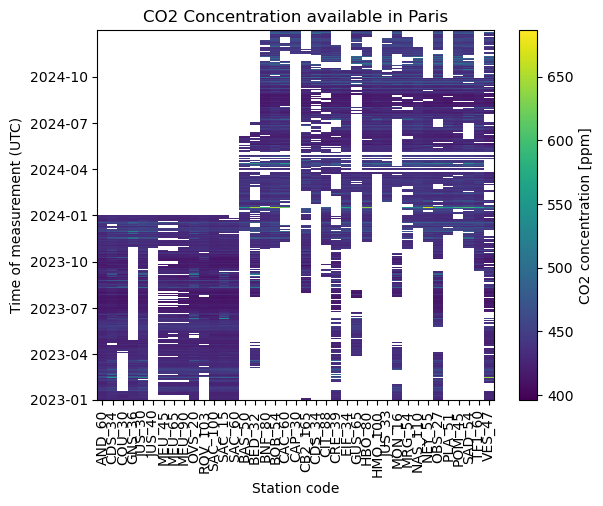

In [7]:
co2.co2.plot.imshow()
plt.title("CO2 Concentration available in Paris")
plt.xticks(rotation=90)
pass

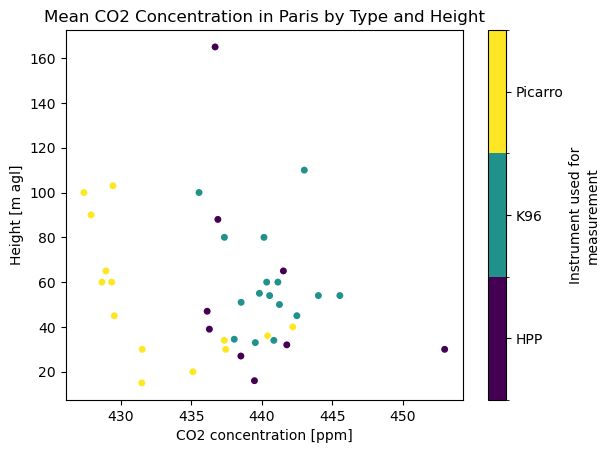

In [8]:
co2.mean("time", keep_attrs=True).plot.scatter(hue="instrument", x="co2", y="height")
plt.title("Mean CO2 Concentration in Paris by Type and Height")
plt.show()

640490.0 6854570.0 659700.0 6869760.0


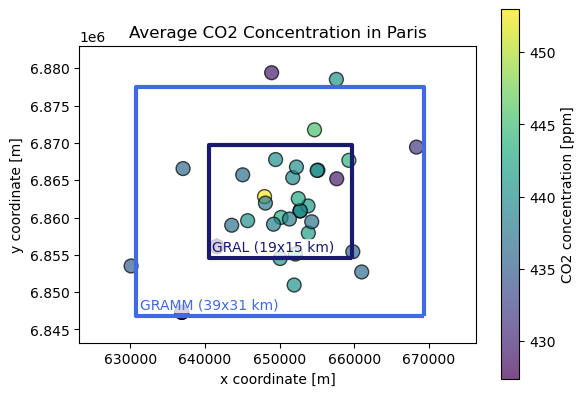

In [9]:
co2.mean("time", keep_attrs=True).plot.scatter(
    x="x",
    y="y",
    hue="co2",
    s=100,
    edgecolor="black",
    alpha=0.7,
    cmap="viridis",
)
p.domain.add_domain(plt.gca())

plt.title("Average CO2 Concentration in Paris")
plt.show()

640490.0 6854570.0 659700.0 6869760.0


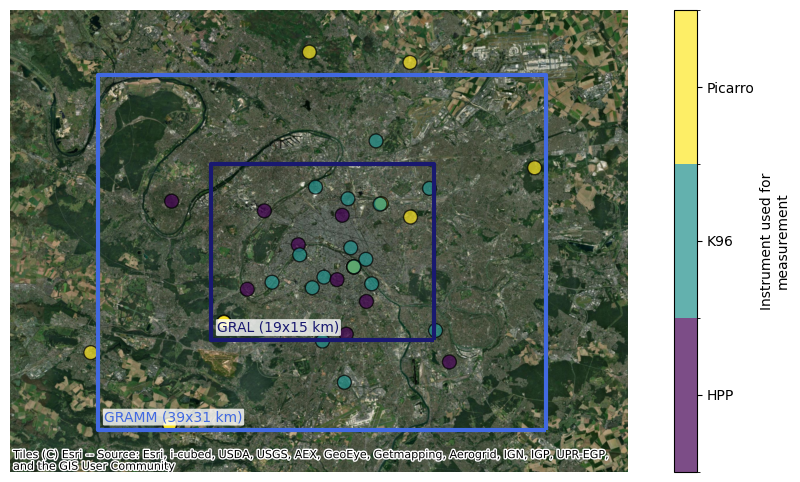

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
co2.plot.scatter(
    x="x",
    y="y",
    hue="instrument",
    s=100,
    edgecolor="black",
    alpha=0.7,
    cmap="viridis",
)
p.domain.add_domain(ax)
p.domain.add_basemap(ax, zoom=12)
plt.show()